# Exploratory Data Analysis — BSDS500 → Edge-Pixel Dataset

**Course:** ED408 (Statistical / Supervised Machine Learning Lab)

This notebook explores:
1. The raw **BSDS500** image segmentation dataset (`archive/`) — image sizes,
   samples, boundary annotation density.
2. The **derived tabular dataset** (`data/bsds_features.csv`) that all 7 lab
   questions are built on: one row per sampled pixel, features = colour /
   gradient / texture / position, label = `is_edge`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

sns.set_theme(style="whitegrid")
ROOT = Path("..").resolve()
plt.rcParams["figure.dpi"] = 100


Matplotlib is building the font cache; this may take a moment.


## 1. Raw BSDS500 image dataset

In [2]:
img_dir = ROOT / "archive" / "images"
for split in ["train", "val", "test"]:
    n = len(list((img_dir / split).glob("*.jpg")))
    print(f"{split:5s}: {n} images")


train: 200 images
val  : 100 images
test : 200 images


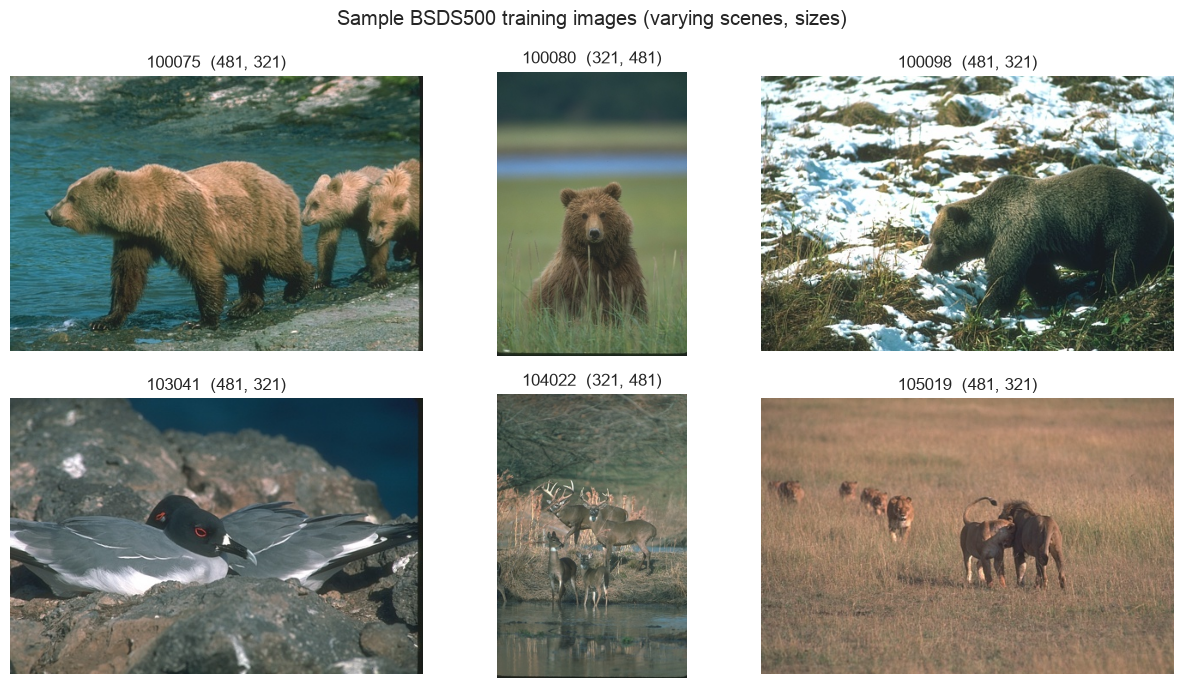

In [3]:
sample_paths = sorted((img_dir / "train").glob("*.jpg"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, p in zip(axes.ravel(), sample_paths):
    im = Image.open(p)
    ax.imshow(im)
    ax.set_title(f"{p.stem}  {im.size}")
    ax.axis("off")
plt.suptitle("Sample BSDS500 training images (varying scenes, sizes)")
plt.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "eda_sample_images.png", bbox_inches="tight")
plt.show()


In [4]:
sizes = [Image.open(p).size for p in sample_paths + sorted((img_dir/"train").glob("*.jpg"))[6:40]]
widths, heights = zip(*sizes)
print("Unique (w,h) combos:", sorted(set(sizes)))


Unique (w,h) combos: [(321, 481), (481, 321)]


BSDS500 images are all either 481x321 (landscape) or 321x481 (portrait) —
a fixed-size natural image benchmark. Each has 5-7 independent human
segmentations (`archive/ground_truth/`) marking object boundaries.

annotators for this image: 6


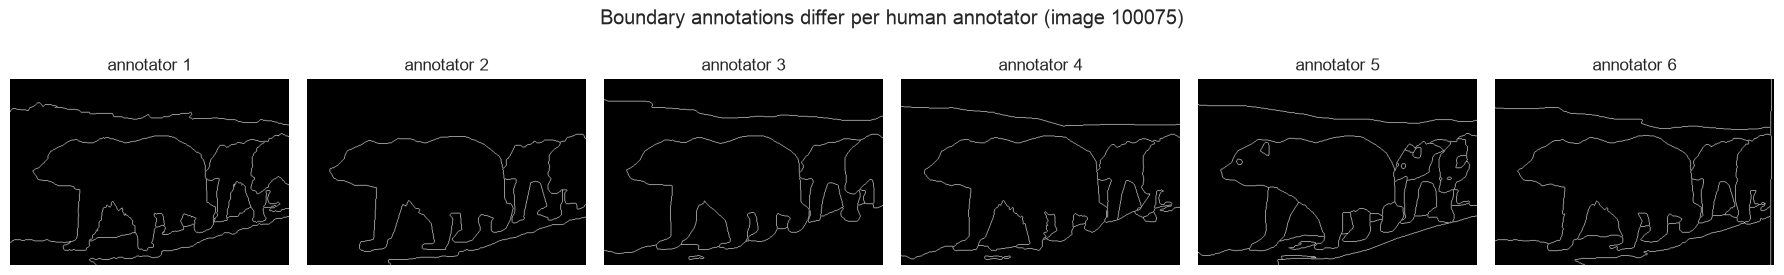

In [5]:
import scipy.io as sio
mat = sio.loadmat(ROOT / "archive" / "ground_truth" / "train" / "100075.jpg".replace(".jpg", ".mat"))
gt = mat["groundTruth"]
print("annotators for this image:", gt.shape[1])

fig, axes = plt.subplots(1, gt.shape[1], figsize=(18, 3))
for i, ax in enumerate(axes):
    b = gt[0, i][0, 0]["Boundaries"]
    ax.imshow(b, cmap="gray")
    ax.set_title(f"annotator {i+1}")
    ax.axis("off")
plt.suptitle("Boundary annotations differ per human annotator (image 100075)")
plt.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "eda_annotator_boundaries.png", bbox_inches="tight")
plt.show()


## 2. Derived tabular dataset (`data/bsds_features.csv`)

Built by `scripts/build_dataset.py`: a balanced sample of edge / non-edge pixels across all 200 training images, with colour, gradient, texture and position features. This is the dataset used, unchanged, for every question in this lab.

In [6]:
df = pd.read_csv(ROOT / "data" / "bsds_features.csv")
print(df.shape)
df.head()


(24000, 12)


,image_id,R,G,B,gray,grad_mag,grad_dir,laplacian,local_std,x_norm,y_norm,is_edge
0,100075,0.094118,0.152941,0.164706,0.137255,0.111271,0.643501,0.019608,0.038649,0.775000,0.756250,1
1,100075,0.345098,0.415686,0.368627,0.376471,0.221345,1.096396,0.079739,0.112371,0.510417,0.309375,1
2,100075,0.286275,0.423529,0.400000,0.369935,0.046494,0.209640,0.047059,0.070415,0.733333,0.400000,1
3,100075,0.258824,0.427451,0.388235,0.358170,0.123617,2.827268,0.118954,0.082925,0.095833,0.534375,1
4,100075,0.094118,0.196078,0.184314,0.158170,0.205713,1.386315,0.113726,0.071222,0.643750,0.734375,1


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
image_id,24000.0,158443.875000,102480.122229,2092.000000,66066.000000,152082.000000,231270.750000,388016.000000
R,24000.0,0.440600,0.242240,0.000000,0.254902,0.415686,0.596078,1.000000
G,24000.0,0.444225,0.229297,0.000000,0.270588,0.423529,0.588235,1.000000
B,24000.0,0.369202,0.238257,0.000000,0.188235,0.333333,0.521569,1.000000
gray,24000.0,0.418009,0.222949,0.000000,0.245752,0.393464,0.562091,1.000000
grad_mag,24000.0,0.155698,0.171484,0.000000,0.030590,0.093194,0.220708,0.993153
grad_dir,24000.0,0.041444,1.819200,-3.141592,-1.545269,0.000000,1.616220,3.141592
laplacian,24000.0,0.134329,0.169303,0.000000,0.020915,0.070588,0.184314,1.777777
local_std,24000.0,0.087194,0.074291,0.000000,0.027687,0.068262,0.127431,0.423635
x_norm,24000.0,0.498596,0.268560,0.008333,0.275000,0.500000,0.721875,0.991667


In [8]:
print(df.isna().sum().sum(), "missing values")
print(df["is_edge"].value_counts(normalize=True))


0 missing values
is_edge
1    0.5
0    0.5
Name: proportion, dtype: float64


### Class balance

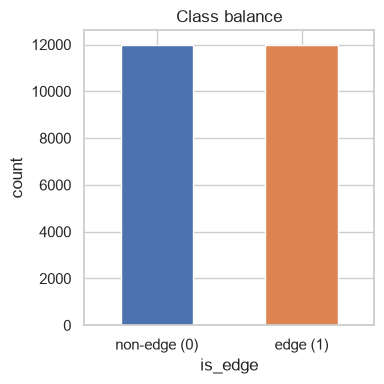

In [9]:
fig, ax = plt.subplots(figsize=(4,4))
df["is_edge"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["non-edge (0)", "edge (1)"], rotation=0)
ax.set_ylabel("count")
ax.set_title("Class balance")
plt.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "eda_class_balance.png", bbox_inches="tight")
plt.show()


### Feature distributions by class

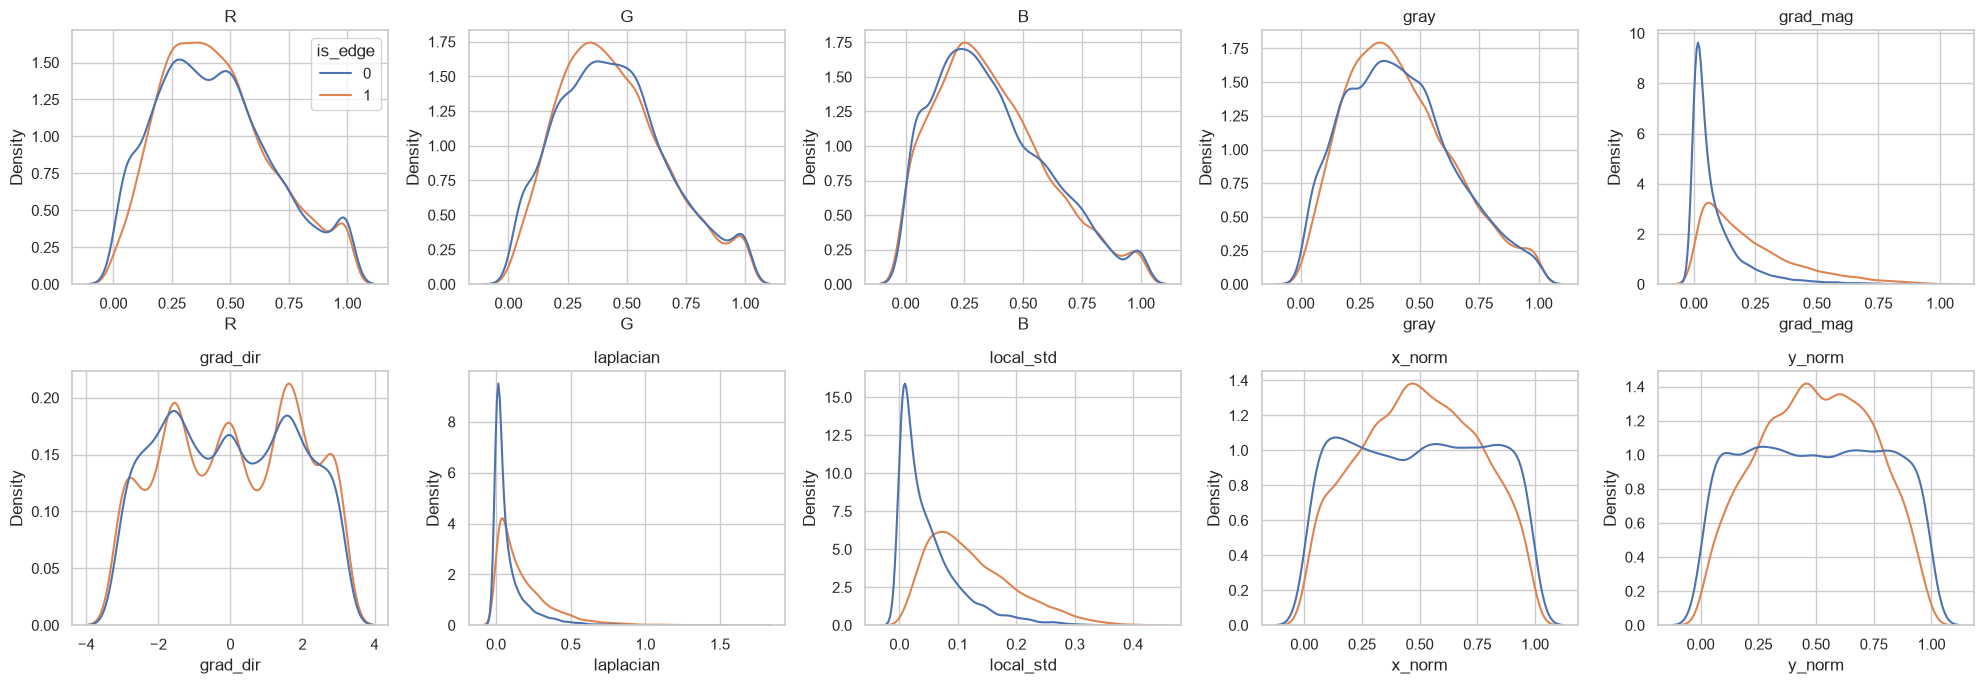

In [10]:
feature_cols = ["R","G","B","gray","grad_mag","grad_dir","laplacian","local_std","x_norm","y_norm"]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), feature_cols):
    sns.kdeplot(data=df, x=col, hue="is_edge", ax=ax, common_norm=False, legend=(col=="R"))
    ax.set_title(col)
plt.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "eda_feature_distributions.png", bbox_inches="tight")
plt.show()


`grad_mag`, `laplacian` and `local_std` clearly separate the two classes (edges have higher gradient/texture energy), while `R,G,B` and position are much less discriminative on their own — this is exactly what we'd expect for an edge-detection task, and gives later classifiers real signal to learn from.

### Correlation heatmap

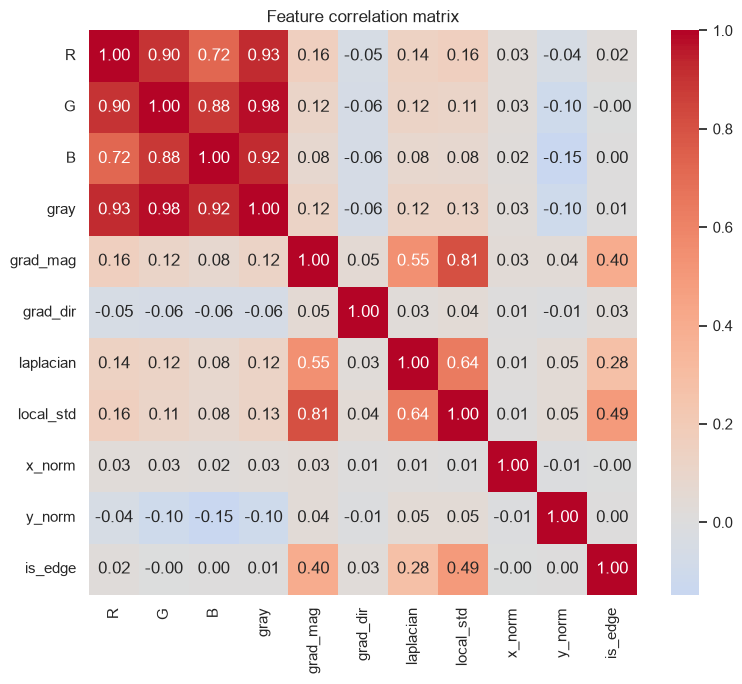

In [11]:
corr = df[feature_cols + ["is_edge"]].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.savefig(ROOT / "results" / "figures" / "eda_correlation.png", bbox_inches="tight")
plt.show()


### Pairplot of the strongest predictors

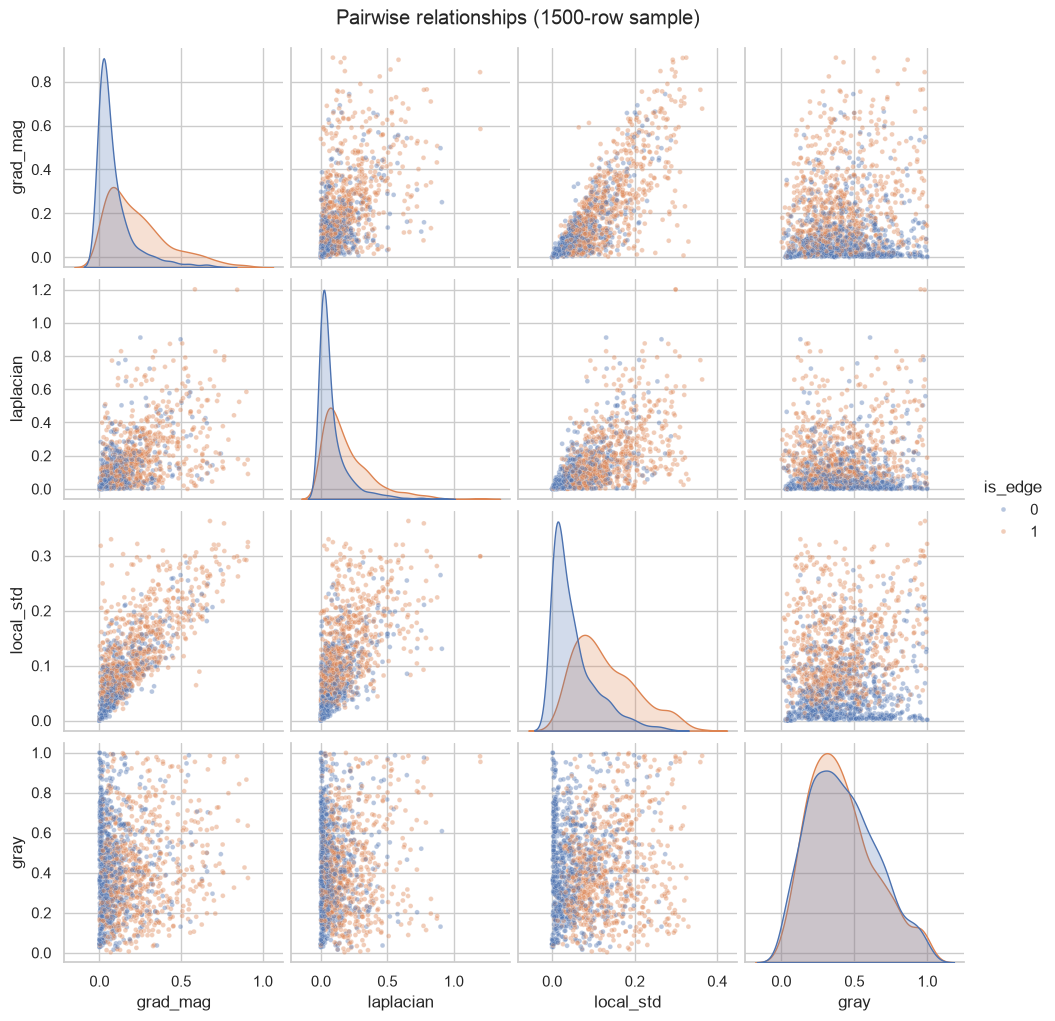

In [12]:
sub = df.sample(1500, random_state=42)
g = sns.pairplot(sub, vars=["grad_mag","laplacian","local_std","gray"], hue="is_edge",
                  plot_kws=dict(alpha=0.4, s=12), diag_kind="kde")
g.fig.suptitle("Pairwise relationships (1500-row sample)", y=1.02)
g.savefig(ROOT / "results" / "figures" / "eda_pairplot.png", bbox_inches="tight")


## Summary

- BSDS500 is an *image segmentation* benchmark; we reframed it as a
  **binary pixel classification** problem (edge vs. non-edge) so that
  standard tabular ML techniques (kNN, Decision Trees, Naive Bayes,
  Logistic Regression, PCA/t-SNE, outlier detection, SVM) can be applied
  meaningfully.
- The derived dataset (`data/bsds_features.csv`) is clean (no missing
  values), perfectly balanced, and its gradient/texture features show
  clear separation between classes — a learnable, well-posed
  classification problem.
- This single dataset is reused, unmodified, across every question in
  this lab.